# Notebook 04 (Exp 3) — LoRA Fine-Tuning

Changes vs Exp 2:
- **Unidirectional training** (Mod→Shak only) — exp1/2 split capacity across both directions; focusing on one direction improves primary task performance
- **LoRA r=32, alpha=64** — doubles trainable params (~26M vs ~13M) for better archaic vocabulary absorption
- Same `EarlyStoppingCallback(patience=3)` and 2-epoch cap as exp2

**Trainable params**: ~26M (~0.8% of 3B)  
**Output**: `outputs/exp3/lora/`

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import sys
import gc
import json
from pathlib import Path

import torch
import pandas as pd
import matplotlib.pyplot as plt

torch.set_float32_matmul_precision('high')

_here = Path.cwd()
ROOT = next(p for p in (_here, _here.parent) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

from src.model_utils import load_model_and_tokenizer, print_model_info
from src.data_utils import load_jsonl_as_hf_dataset, load_jsonl, SYSTEM_PROMPT_MOD2SHAK
from src.training_utils import build_lora_config, build_lora_training_args_exp2

from transformers import EarlyStoppingCallback
from trl import SFTTrainer
from datasets import Dataset

PROCESSED_DIR = ROOT / 'data' / 'processed'
HF_CACHE      = ROOT / 'data' / 'raw' / 'huggingface_cache'
OUTPUT_DIR    = ROOT / 'outputs' / 'exp3' / 'lora'
FIG_DIR       = ROOT / 'outputs' / 'exp3' / 'results' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

MODEL_ID = 'Qwen/Qwen2.5-3B-Instruct'
print('Setup complete.')
print(f'ROOT: {ROOT}')
print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

Setup complete.
ROOT: C:\Users\pra73\Desktop\Projects\Active_Gits\Mormon-NLT
GPU: NVIDIA GeForce RTX 5070 Laptop GPU
VRAM: 8.5 GB


## 1. Build Unidirectional Training Split

Filter `train.jsonl` to Mod→Shak records only and cache as `train_uni.jsonl`.  
This halves the dataset size but focuses all learning on the primary direction.

In [2]:
UNI_TRAIN = PROCESSED_DIR / 'train_uni.jsonl'

if not UNI_TRAIN.exists():
    print('Building train_uni.jsonl (Mod→Shak only) ...')
    all_records = load_jsonl(PROCESSED_DIR / 'train.jsonl')
    uni_records = [r for r in all_records
                   if r['messages'][0]['content'] == SYSTEM_PROMPT_MOD2SHAK]
    with open(UNI_TRAIN, 'w', encoding='utf-8') as f:
        for rec in uni_records:
            f.write(json.dumps(rec, ensure_ascii=False) + '\n')
    print(f'Saved {len(uni_records):,} Mod→Shak records to {UNI_TRAIN}')
else:
    all_records = load_jsonl(PROCESSED_DIR / 'train.jsonl')
    uni_records = [r for r in all_records
                   if r['messages'][0]['content'] == SYSTEM_PROMPT_MOD2SHAK]
    print(f'train_uni.jsonl already exists ({len(uni_records):,} records)')

print(f'Bidirectional train size:   {len(all_records):,} records')
print(f'Unidirectional train size:  {len(uni_records):,} records  (Mod→Shak only)')


train_uni.jsonl already exists (20,042 records)
Bidirectional train size:   40,084 records
Unidirectional train size:  20,042 records  (Mod→Shak only)


In [3]:
train_dataset = load_jsonl_as_hf_dataset(UNI_TRAIN)
val_dataset   = load_jsonl_as_hf_dataset(PROCESSED_DIR / 'val.jsonl')

print('Train (unidirectional):', train_dataset)
print('Val:                   ', val_dataset)


Train (unidirectional): Dataset({
    features: ['messages'],
    num_rows: 20042
})
Val:                    Dataset({
    features: ['messages'],
    num_rows: 2234
})


## 2. Load Model with 4-bit QLoRA

In [4]:
model, tokenizer = load_model_and_tokenizer(
    MODEL_ID,
    quantization='4bit',
    attn_implementation='sdpa',
)
model.enable_input_require_grads()

print_model_info(model)

if torch.cuda.is_available():
    print(f'VRAM used after load: {torch.cuda.memory_allocated(0)/1e9:.2f} GB')


W0406 21:58:05.727000 24208 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

C:\Users\pra73\.conda\envs\advnlp\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Total parameters:     1,698,672,640
Trainable parameters: 311,406,592  (18.33%)
VRAM used after load: 2.06 GB


## 3. LoRA Config — r=32, alpha=64

In [5]:
# r=32: doubles trainable params vs exp1/2 (r=16) — gives model more capacity
# to learn archaic vocabulary patterns without large VRAM increase
lora_config = build_lora_config(r=32, lora_alpha=64, lora_dropout=0.05)
print('LoRA config (Exp 3):')
print(f'  r:               {lora_config.r}  (exp1/2: 16)')
print(f'  lora_alpha:      {lora_config.lora_alpha}  (exp1/2: 32)')
print(f'  scale (a/r):     {lora_config.lora_alpha / lora_config.r:.1f}')
print(f'  target_modules:  {lora_config.target_modules}')


LoRA config (Exp 3):
  r:               32  (exp1/2: 16)
  lora_alpha:      64  (exp1/2: 32)
  scale (a/r):     2.0
  target_modules:  {'gate_proj', 'v_proj', 'up_proj', 'o_proj', 'k_proj', 'down_proj', 'q_proj'}


## 4. Training Configuration (same as Exp 2 — 2 epochs + EarlyStopping)

In [6]:
training_args = build_lora_training_args_exp2(
    output_dir=str(OUTPUT_DIR / 'checkpoints'),
    per_device_train_batch_size=2,
    gradient_accumulation_steps=8,
    max_length=256,
    optim='paged_adamw_32bit',
)

print('Training arguments (Exp 3 LoRA):')
print(f'  num_train_epochs:    {training_args.num_train_epochs}  (+ EarlyStoppingCallback)')
print(f'  learning_rate:       {training_args.learning_rate}')
print(f'  effective batch:     {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}')
print(f'  optimizer:           {training_args.optim}')


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training arguments (Exp 3 LoRA):
  num_train_epochs:    2  (+ EarlyStoppingCallback)
  learning_rate:       0.0002
  effective batch:     16
  optimizer:           OptimizerNames.PAGED_ADAMW


## 5. Train

In [7]:
trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    peft_config=lora_config,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

# Check if complete, or find latest checkpoint to resume
_final = OUTPUT_DIR / 'final_adapter'
if _final.exists():
    print(f'Training already complete — found {_final}')
    print('Delete final_adapter/ to re-train.')
    train_result = None
else:
    _ckpts = sorted(
        (OUTPUT_DIR / 'checkpoints').glob('checkpoint-*'),
        key=lambda p: int(p.name.split('-')[-1])
    ) if (OUTPUT_DIR / 'checkpoints').exists() else []
    _resume = str(_ckpts[-1]) if _ckpts else None
    print(f'Resuming from: {_resume}' if _resume else 'Starting QLoRA (Exp 3: r=32, unidirectional) training from scratch ...')
    train_result = trainer.train(resume_from_checkpoint=_resume)
    print(f'\nTraining complete.')
    print(f'  Train loss: {train_result.training_loss:.4f}')
    print(f'  Steps:      {train_result.global_step}')

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Starting QLoRA (Exp 3: r=32, unidirectional) training from scratch ...


Step,Training Loss,Validation Loss
200,1.047462,0.997756
400,1.030601,0.982523
600,0.982201,0.972406
800,0.951910,0.966578
1000,0.978980,0.958484
1200,0.965419,0.952982
1400,0.872795,0.956976
1600,0.850901,0.957233
1800,0.882517,0.953338



Training complete.
  Train loss: 0.9964
  Steps:      1800


## 6. Save Adapter and Log History

In [8]:
adapter_path = str(OUTPUT_DIR / 'final_adapter')
trainer.save_model(adapter_path)
tokenizer.save_pretrained(adapter_path)
print(f'LoRA adapter (Exp 3) saved to: {adapter_path}')

log_path = OUTPUT_DIR / 'training_logs' / 'lora_log_history.json'
log_path.parent.mkdir(parents=True, exist_ok=True)
with open(log_path, 'w') as f:
    json.dump(trainer.state.log_history, f)
print(f'Log history saved to: {log_path}')

LoRA adapter (Exp 3) saved to: C:\Users\pra73\Desktop\Projects\Active_Gits\Mormon-NLT\outputs\exp3\lora\final_adapter
Log history saved to: C:\Users\pra73\Desktop\Projects\Active_Gits\Mormon-NLT\outputs\exp3\lora\training_logs\lora_log_history.json


## 7. Training Loss Curve

Loaded 46 entries from lora_log_history.json.


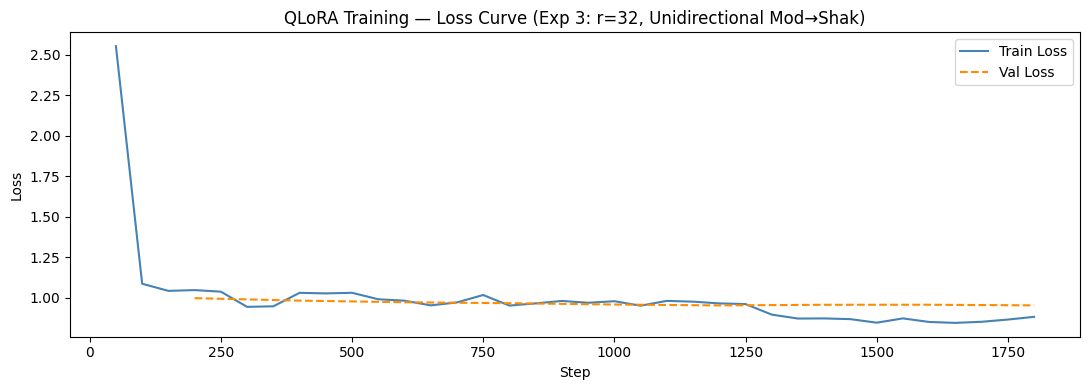

In [9]:
log_path = OUTPUT_DIR / 'training_logs' / 'lora_log_history.json'
if log_path.exists():
    with open(log_path) as f:
        log_history = json.load(f)
    print(f'Loaded {len(log_history)} entries from {log_path.name}.')
else:
    log_history = trainer.state.log_history
    print('Using in-memory trainer log history.')
log_df = pd.DataFrame(log_history)
train_loss = log_df[log_df['loss'].notna()][['step', 'loss']]
eval_loss  = log_df[log_df['eval_loss'].notna()][['step', 'eval_loss']]

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(train_loss['step'], train_loss['loss'], label='Train Loss', color='steelblue')
ax.plot(eval_loss['step'], eval_loss['eval_loss'], label='Val Loss', color='darkorange', linestyle='--')
ax.set_xlabel('Step'); ax.set_ylabel('Loss')
ax.set_title('QLoRA Training — Loss Curve (Exp 3: r=32, Unidirectional Mod→Shak)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'exp3_lora_loss_curve.png', dpi=150)
plt.show()


In [10]:
del model, trainer
gc.collect()
torch.cuda.empty_cache()
print('Memory freed.')


Memory freed.
